In [2]:
# Check if autoreload is loaded and load/reload accordingly
try:
    %reload_ext autoreload
except:
    %load_ext autoreload
%autoreload 2
import numpy as np
import h5py
import yaml
import pandas as pd
from scipy.optimize import minimize

from sklearn.preprocessing import OneHotEncoder
from theory_helper_funcs import (activity_func_generator, min_mse_loss, min_mse_loss_reg, extend_sequences, load_kinetic_data)

import matplotlib.pyplot as plt


In [5]:
# King-Altman function and regression with binary selectors
data = load_kinetic_data(
    "/Users/alamson/projects/Elektrum/theory_notebooks/ring_datasets/test_4ring_random_0.h5",
    template_seq="AAAAAAA",
    mutant_seq="BBBBBBB"
)
x = data['x']
y = data['y']
ka_mat = data['ka_mat']

f = activity_func_generator(data['ka_mat'], data['ka_contrib'])

# ---- Step 5: Optimization to recover a, b ----
n = x.shape[1]  # Number of dimensions
# theta0 = np.random.uniform(-3, 3, size=2 * n)  # Initial guess

theta0 = [0]*(2*n)  # Initial guess

# Run optimizer
result = minimize(
    min_mse_loss, theta0, args=(f, x, y), method="L-BFGS-B", bounds=[(-10, 4)] * (2 * n)
)

# Extract results
estimated_theta = result.x
estimated_a = estimated_theta[::2]
estimated_b = estimated_theta[1::2]

# Analyze optimization quality
print("\n" + "="*50)
print("OPTIMIZATION RESULTS")
print("="*50)
print(f"Success: {result.success}")
print(f"Message: {result.message}")
print(f"Final loss: {result.fun:.6e}")
print(f"Iterations: {result.nit}")
print(f"Function evals: {result.nfev}")

if hasattr(result, 'jac'):
    grad_norm = np.linalg.norm(result.jac)
    print(f"Gradient norm: {grad_norm:.6e}")

print("True k_target:", data['target_rates'])
print("Estimated k_target:", np.exp(estimated_a))
print("True k_mut:", data['mut_rates'])
print("Estimated k_mut:", np.exp(estimated_b))



OPTIMIZATION RESULTS
Success: True
Message: b'CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH'
Final loss: 9.946312e-06
Iterations: 128
Function evals: 2070
Gradient norm: 8.849370e-05
True k_target: [3.8079472, 2.293003, 7.3467402, 0.16102308, 1.6445845, 1.3706979, 0.6750278]
Estimated k_target: [2.85873649 0.21288742 4.85706163 0.16038601 1.65285616 1.46943269
 0.71889863]
True k_mut: [3.6251984, 9.402922, 4.4383225, 9.863131, 0.34094673, 3.572855, 0.59807533]
Estimated k_mut: [2.69935979 3.74160542 2.93998663 9.81272754 0.3427819  3.8235533
 0.63536241]


In [ ]:
# King-Altman function and regression with binary selectors
data = load_kinetic_data(
    "/Users/alamson/projects/Elektrum/theory_notebooks/ring_datasets/test_4ring_random_1.h5",
    template_seq="AAAAAAA",
    mutant_seq="BBBBBBB"
)
x = data['x']
y = data['y']
ka_mat = data['ka_mat']

f = activity_func_generator(data['ka_mat'], data['ka_contrib'])

n = x.shape[1] 
theta0 = np.random.uniform(-3, 3, size=2 * n)  # Initial guess

result = minimize(
    min_mse_loss, theta0, args=(f, x, y), method="L-BFGS-B", bounds=[(-4, 4)] * (2 * n)
)

# Extract results
estimated_theta = result.x
estimated_a = estimated_theta[::2]
estimated_b = estimated_theta[1::2]

# Analyze optimization quality
print("\n" + "="*50)
print("OPTIMIZATION RESULTS")
print("="*50)
print(f"Success: {result.success}")
print(f"Message: {result.message}")
print(f"Final loss: {result.fun:.6e}")
print(f"Iterations: {result.nit}")
print(f"Function evals: {result.nfev}")

if hasattr(result, 'jac'):
    grad_norm = np.linalg.norm(result.jac)
    print(f"Gradient norm: {grad_norm:.6e}")

print("True k_target:", data['target_rates'])
print("Estimated k_target:", np.exp(estimated_a))
print("True k_mut:", data['mut_rates'])
print("Estimated k_mut:", np.exp(estimated_b))



OPTIMIZATION RESULTS
Success: True
Message: b'CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH'
Final loss: 5.254362e-09
Iterations: 157
Function evals: 3000
Gradient norm: 1.006766e-04
True k_target: [1.9000672, 0.562173, 3.1119983, 1.4247283, 4.3762555, 0.88182676, 6.157344]
Estimated k_target: [1.90034312 0.56222145 3.11159768 1.42378873 4.37508072 0.88167856
 6.156904  ]
True k_mut: [0.43014044, 4.2891555, 1.6805655, 9.29797, 1.3453703, 6.0727477, 0.94496226]
Estimated k_mut: [0.43016656 4.28977738 1.68033977 9.29415602 1.34499393 6.07201312
 0.94489539]


In [54]:
# King-Altman function and regression with binary selectors
data = load_kinetic_data(
    "/Users/alamson/projects/Elektrum/theory_notebooks/ring_datasets/test_4ring_random_2.h5",
    template_seq="AAAAAAA",
    mutant_seq="BBBBBBB"
)
x = data['x']
y = data['y']
ka_mat = data['ka_mat']

f = activity_func_generator(data['ka_mat'], data['ka_contrib'])

# ---- Step 5: Optimization to recover a, b ----
n = x.shape[1]  # Number of dimensions
theta0 = np.random.uniform(-3, 3, size=2 * n)  # Initial guess

# Run optimizer
result = minimize(
    min_mse_loss, theta0, args=(f, x, y), method="L-BFGS-B", bounds=[(-4, 4)] * (2 * n)
)

# Extract results
estimated_theta = result.x
estimated_a = estimated_theta[::2]
estimated_b = estimated_theta[1::2]

# Analyze optimization quality
print("\n" + "="*50)
print("OPTIMIZATION RESULTS")
print("="*50)
print(f"Success: {result.success}")
print(f"Message: {result.message}")
print(f"Final loss: {result.fun:.6e}")
print(f"Iterations: {result.nit}")
print(f"Function evals: {result.nfev}")

if hasattr(result, 'jac'):
    grad_norm = np.linalg.norm(result.jac)
    print(f"Gradient norm: {grad_norm:.6e}")

print("True k_target:", data['target_rates'])
print("Estimated k_target:", np.exp(estimated_a))
print("True k_mut:", data['mut_rates'])
print("Estimated k_mut:", np.exp(estimated_b))



OPTIMIZATION RESULTS
Success: True
Message: b'CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH'
Final loss: 1.015077e-06
Iterations: 134
Function evals: 2250
Gradient norm: 4.799729e-05
True k_target: [5.9649043, 1.8239459, 6.114694, 4.187033, 0.74401075, 0.09957738, 9.659757]
Estimated k_target: [5.98862287 1.82999896 6.26568304 4.37084862 0.75057046 0.04140607
 8.14881497]
True k_mut: [0.37242723, 2.8908997, 1.1256504, 8.644543, 0.71109253, 5.1018286, 7.828082]
Estimated k_mut: [0.37361328 2.9005672  1.15397729 9.00399937 0.71724554 4.25446618
 6.60523597]


In [63]:
# King-Altman function and regression with binary selectors
data = load_kinetic_data(
    "/Users/alamson/projects/Elektrum/theory_notebooks/proofreading_datasets/test_4proofreading_random_2.h5",
    template_seq="AAAAAAAA",
    mutant_seq="BBBBBBBB"
)
x = data['x']
y = data['y']
ka_mat = data['ka_mat']

f = activity_func_generator(data['ka_mat'], data['ka_contrib'])

# ---- Step 5: Optimization to recover a, b ----
n = x.shape[1]  # Number of dimensions
theta0 = np.random.uniform(-3, 3, size=2 * n)  # Initial guess

# Run optimizer
result = minimize(
    min_mse_loss, theta0, args=(f, x, y), method="L-BFGS-B", bounds=[(-4, 4)] * (2 * n)
)

# Extract results
estimated_theta = result.x
estimated_a = estimated_theta[::2]
estimated_b = estimated_theta[1::2]

# Analyze optimization quality
print("\n" + "="*50)
print("OPTIMIZATION RESULTS")
print("="*50)
print(f"Success: {result.success}")
print(f"Message: {result.message}")
print(f"Final loss: {result.fun:.6e}")
print(f"Iterations: {result.nit}")
print(f"Function evals: {result.nfev}")

if hasattr(result, 'jac'):
    grad_norm = np.linalg.norm(result.jac)
    print(f"Gradient norm: {grad_norm:.6e}")

print("True k_target:", data['target_rates'])
print("Estimated k_target:", np.exp(estimated_a))
print("True k_mut:", data['mut_rates'])
print("Estimated k_mut:", np.exp(estimated_b))



OPTIMIZATION RESULTS
Success: True
Message: b'CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH'
Final loss: 3.299889e-05
Iterations: 142
Function evals: 2890
Gradient norm: 2.970608e-05
True k_target: [0.74401075, 0.09957738, 9.659757, 0.34184086, 3.1156764, 0.81368685, 6.873907, 0.63030505]
Estimated k_target: [0.74624584 0.02435143 8.80125409 0.50024228 1.83751984 0.81548648
 6.87492754 0.07288195]
True k_mut: [0.71109253, 5.1018286, 7.828082, 9.444113, 0.3945475, 7.4726577, 3.081552, 5.8789783]
Estimated k_mut: [0.70810186 4.57855145 7.13224308 5.87485716 0.23242428 7.47517827
 3.08358571 3.16625909]


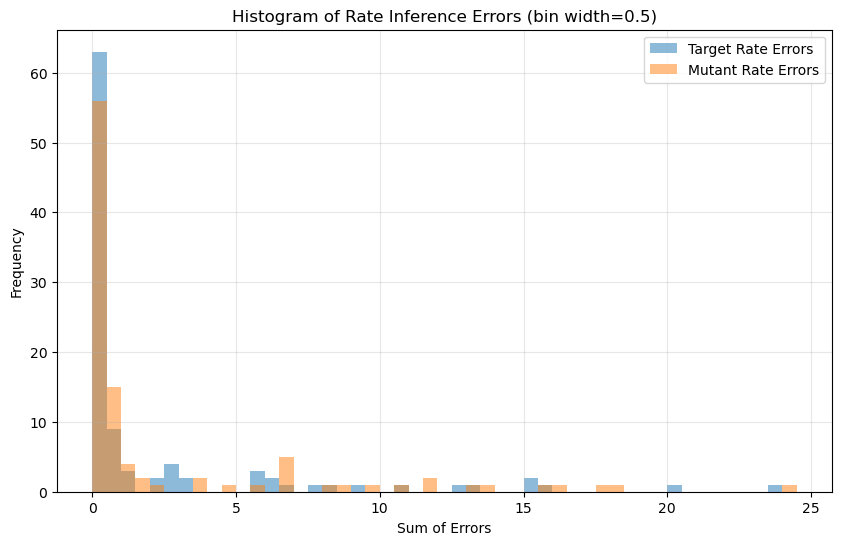

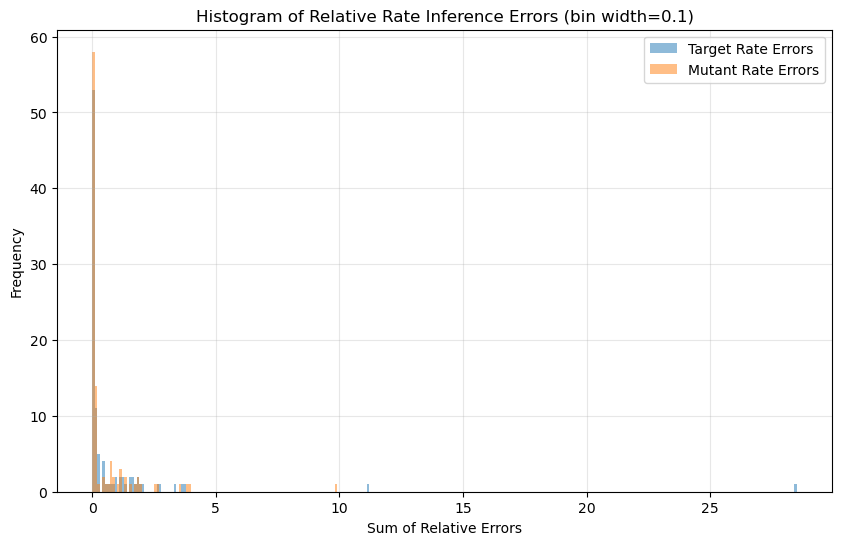

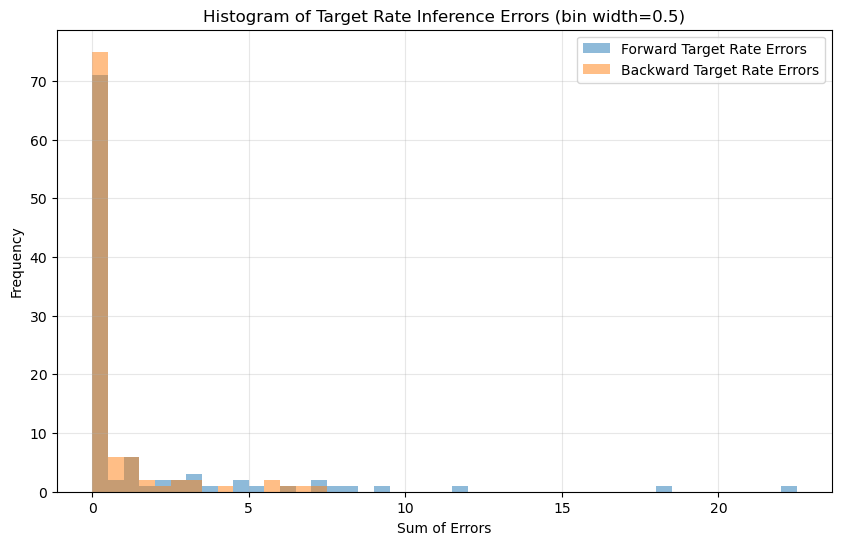

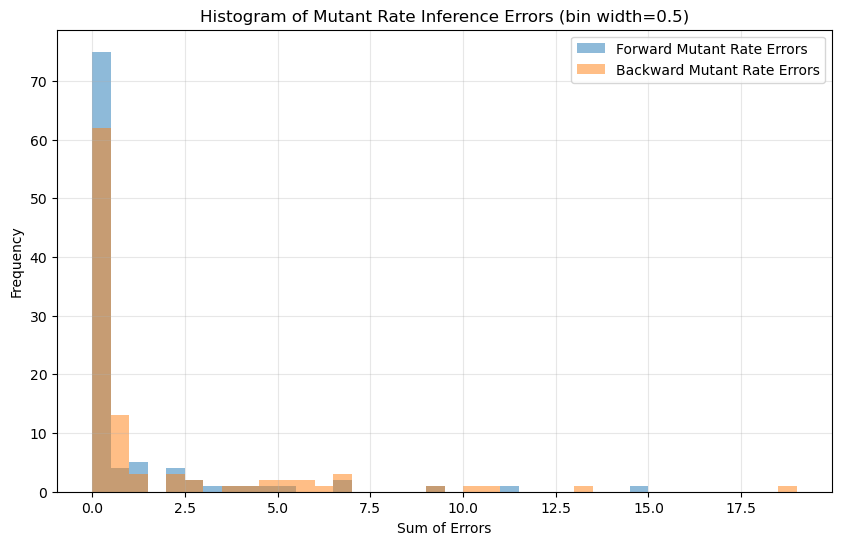

In [3]:
import numpy as np
import matplotlib.pyplot as plt

dataset_file = "/Users/alamson/projects/Elektrum/theory_notebooks/ring_datasets_inferred_params.h5"

with h5py.File(dataset_file, "r") as f:
    rates = f['rates'][:]
    n_reps = rates.shape[-1]
    
    # Calculate errors
    target_rate_errs = []
    mut_rate_errs = []
    rel_target_rate_errs = []
    rel_mut_rate_errs = []
    
    for i in range(n_reps):
        target_rate_err = np.abs(rates[0, :, i] - rates[1, :, i])
        mut_rate_err = np.abs(rates[2, :, i] - rates[3, :, i])
        
        target_rate_errs.append(target_rate_err)
        mut_rate_errs.append(mut_rate_err)
        rel_target_rate_errs.append(target_rate_err / rates[1, :, i])
        rel_mut_rate_errs.append(mut_rate_err / rates[3, :, i])

# Calculate error sums
trg_error_sums = [np.sum(errs) for errs in target_rate_errs]
mut_error_sums = [np.sum(errs) for errs in mut_rate_errs]
rel_trg_error_sums = [np.sum(errs) for errs in rel_target_rate_errs]
rel_mut_error_sums = [np.sum(errs) for errs in rel_mut_rate_errs]

# Forward/backward error sums
fwd_error_sums = [np.sum(errs[::2]) for errs in target_rate_errs]
bkwd_error_sums = [np.sum(errs[1::2]) for errs in target_rate_errs]
mut_fwd_error_sums = [np.sum(errs[::2]) for errs in mut_rate_errs]
mut_bkwd_error_sums = [np.sum(errs[1::2]) for errs in mut_rate_errs]

# Define bin width
BIN_WIDTH = 0.5

# Plot 1: Absolute errors
all_abs_errors = np.concatenate([trg_error_sums, mut_error_sums])
abs_bins = np.arange(all_abs_errors.min(), all_abs_errors.max() + BIN_WIDTH, BIN_WIDTH)

plt.figure(figsize=(10, 6))
plt.hist(trg_error_sums, bins=abs_bins, alpha=0.5, label='Target Rate Errors')
plt.hist(mut_error_sums, bins=abs_bins, alpha=0.5, label='Mutant Rate Errors')
plt.xlabel('Sum of Errors')
plt.ylabel('Frequency')
plt.title(f'Histogram of Rate Inference Errors (bin width={BIN_WIDTH})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plot 2: Relative errors
all_rel_errors = np.concatenate([rel_trg_error_sums, rel_mut_error_sums])
rel_bins = np.arange(all_rel_errors.min(), all_rel_errors.max() + BIN_WIDTH*.2, BIN_WIDTH*.2)

plt.figure(figsize=(10, 6))
plt.hist(rel_trg_error_sums, bins=rel_bins, alpha=0.5, label='Target Rate Errors')
plt.hist(rel_mut_error_sums, bins=rel_bins, alpha=0.5, label='Mutant Rate Errors')
plt.xlabel('Sum of Relative Errors')
plt.ylabel('Frequency')
plt.title(f'Histogram of Relative Rate Inference Errors (bin width={BIN_WIDTH*.2})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plot 3: Forward/backward target errors
all_fwd_bwd = np.concatenate([fwd_error_sums, bkwd_error_sums])
fwd_bwd_bins = np.arange(all_fwd_bwd.min(), all_fwd_bwd.max() + BIN_WIDTH, BIN_WIDTH)

plt.figure(figsize=(10, 6))
plt.hist(fwd_error_sums, bins=fwd_bwd_bins, alpha=0.5, label='Forward Target Rate Errors')
plt.hist(bkwd_error_sums, bins=fwd_bwd_bins, alpha=0.5, label='Backward Target Rate Errors')
plt.xlabel('Sum of Errors')
plt.ylabel('Frequency')
plt.title(f'Histogram of Target Rate Inference Errors (bin width={BIN_WIDTH})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plot 4: Forward/backward mutant errors
all_mut_fwd_bwd = np.concatenate([mut_fwd_error_sums, mut_bkwd_error_sums])
mut_fwd_bwd_bins = np.arange(all_mut_fwd_bwd.min(), all_mut_fwd_bwd.max() + BIN_WIDTH, BIN_WIDTH)

plt.figure(figsize=(10, 6))
plt.hist(mut_fwd_error_sums, bins=mut_fwd_bwd_bins, alpha=0.5, label='Forward Mutant Rate Errors')
plt.hist(mut_bkwd_error_sums, bins=mut_fwd_bwd_bins, alpha=0.5, label='Backward Mutant Rate Errors')
plt.xlabel('Sum of Errors')
plt.ylabel('Frequency')
plt.title(f'Histogram of Mutant Rate Inference Errors (bin width={BIN_WIDTH})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

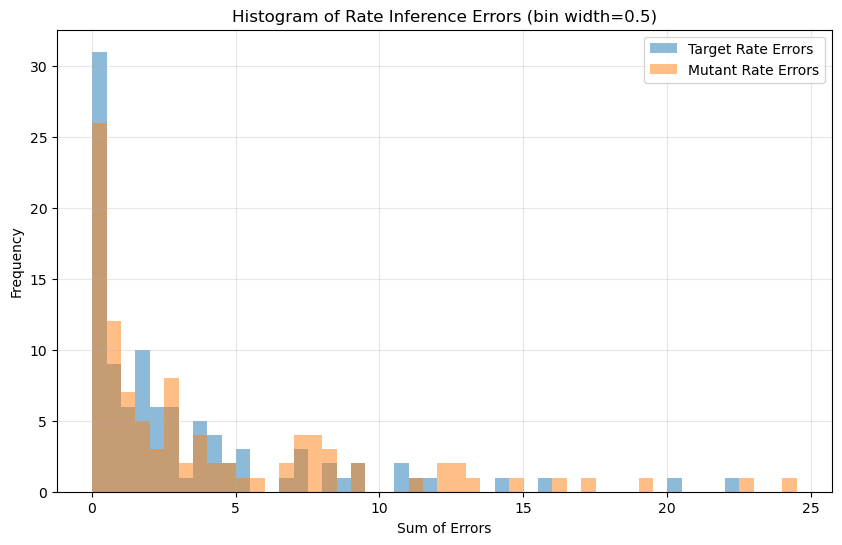

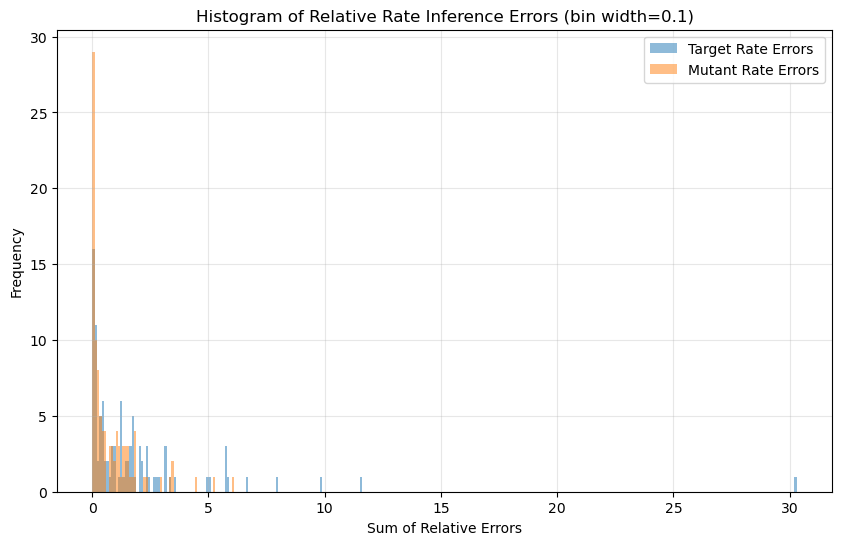

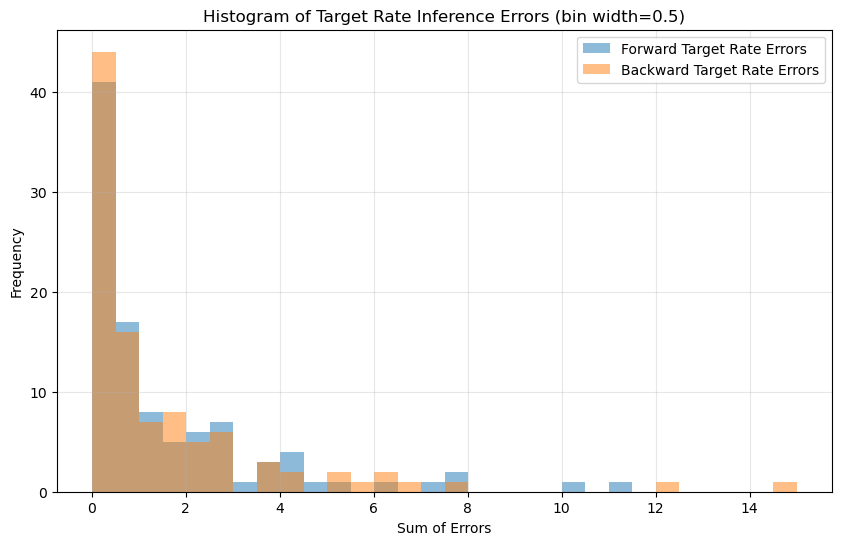

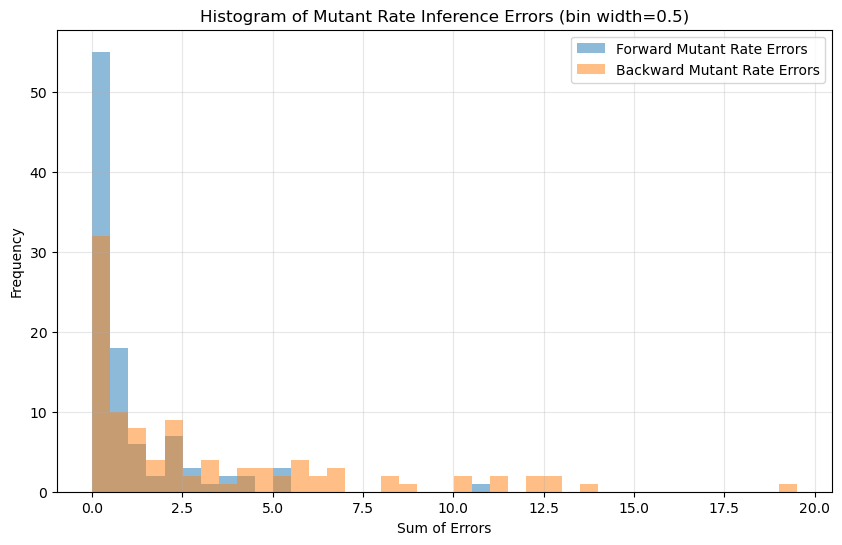

In [21]:
import numpy as np
import matplotlib.pyplot as plt

dataset_file = "/Users/alamson/projects/Elektrum/theory_notebooks/proofreading_datasets_inferred_params.h5"

with h5py.File(dataset_file, "r") as f:
    rates = f['rates'][:]
    n_reps = rates.shape[-1]
    
    # Calculate errors
    target_rate_errs = []
    mut_rate_errs = []
    rel_target_rate_errs = []
    rel_mut_rate_errs = []
    
    for i in range(n_reps):
        target_rate_err = np.abs(rates[0, :, i] - rates[1, :, i])
        mut_rate_err = np.abs(rates[2, :, i] - rates[3, :, i])
        
        target_rate_errs.append(target_rate_err)
        mut_rate_errs.append(mut_rate_err)
        rel_target_rate_errs.append(target_rate_err / rates[1, :, i])
        rel_mut_rate_errs.append(mut_rate_err / rates[3, :, i])

# Calculate error sums
trg_error_sums = [np.sum(errs) for errs in target_rate_errs]
mut_error_sums = [np.sum(errs) for errs in mut_rate_errs]
rel_trg_error_sums = [np.sum(errs) for errs in rel_target_rate_errs]
rel_mut_error_sums = [np.sum(errs) for errs in rel_mut_rate_errs]

# Forward/backward error sums
fwd_error_sums = [np.sum(errs[::2]) for errs in target_rate_errs]
bkwd_error_sums = [np.sum(errs[1::2]) for errs in target_rate_errs]
mut_fwd_error_sums = [np.sum(errs[::2]) for errs in mut_rate_errs]
mut_bkwd_error_sums = [np.sum(errs[1::2]) for errs in mut_rate_errs]

# Define bin width
BIN_WIDTH = 0.5

# Plot 1: Absolute errors
all_abs_errors = np.concatenate([trg_error_sums, mut_error_sums])
abs_bins = np.arange(all_abs_errors.min(), all_abs_errors.max() + BIN_WIDTH, BIN_WIDTH)

plt.figure(figsize=(10, 6))
plt.hist(trg_error_sums, bins=abs_bins, alpha=0.5, label='Target Rate Errors')
plt.hist(mut_error_sums, bins=abs_bins, alpha=0.5, label='Mutant Rate Errors')
plt.xlabel('Sum of Errors')
plt.ylabel('Frequency')
plt.title(f'Histogram of Rate Inference Errors (bin width={BIN_WIDTH})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plot 2: Relative errors
all_rel_errors = np.concatenate([rel_trg_error_sums, rel_mut_error_sums])
rel_bins = np.arange(all_rel_errors.min(), all_rel_errors.max() + BIN_WIDTH*.2, BIN_WIDTH*.2)

plt.figure(figsize=(10, 6))
plt.hist(rel_trg_error_sums, bins=rel_bins, alpha=0.5, label='Target Rate Errors')
plt.hist(rel_mut_error_sums, bins=rel_bins, alpha=0.5, label='Mutant Rate Errors')
plt.xlabel('Sum of Relative Errors')
plt.ylabel('Frequency')
plt.title(f'Histogram of Relative Rate Inference Errors (bin width={BIN_WIDTH*.2})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plot 3: Forward/backward target errors
all_fwd_bwd = np.concatenate([fwd_error_sums, bkwd_error_sums])
fwd_bwd_bins = np.arange(all_fwd_bwd.min(), all_fwd_bwd.max() + BIN_WIDTH, BIN_WIDTH)

plt.figure(figsize=(10, 6))
plt.hist(fwd_error_sums, bins=fwd_bwd_bins, alpha=0.5, label='Forward Target Rate Errors')
plt.hist(bkwd_error_sums, bins=fwd_bwd_bins, alpha=0.5, label='Backward Target Rate Errors')
plt.xlabel('Sum of Errors')
plt.ylabel('Frequency')
plt.title(f'Histogram of Target Rate Inference Errors (bin width={BIN_WIDTH})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plot 4: Forward/backward mutant errors
all_mut_fwd_bwd = np.concatenate([mut_fwd_error_sums, mut_bkwd_error_sums])
mut_fwd_bwd_bins = np.arange(all_mut_fwd_bwd.min(), all_mut_fwd_bwd.max() + BIN_WIDTH, BIN_WIDTH)

plt.figure(figsize=(10, 6))
plt.hist(mut_fwd_error_sums, bins=mut_fwd_bwd_bins, alpha=0.5, label='Forward Mutant Rate Errors')
plt.hist(mut_bkwd_error_sums, bins=mut_fwd_bwd_bins, alpha=0.5, label='Backward Mutant Rate Errors')
plt.xlabel('Sum of Errors')
plt.ylabel('Frequency')
plt.title(f'Histogram of Mutant Rate Inference Errors (bin width={BIN_WIDTH})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()